# Проект. Исследование стартапов

## Введение



**Контекст проекта**: финансовая компания планирует определить наиболее перспективные направления для вложения средств в стартапы. Для этого были предоставлены данные о компаниях, объёмах привлечённого финансирования, типах финансирования и возврате средств инвесторам за разные годы.

**Цель проекта**: провести анализ данных о финансировании стартапов и оценить эффективность различных отраслей и типов финансирования. На основе результатов исследования необходимо определить, в какие сегменты рынка целесообразно инвестировать и какой способ финансирования может обеспечить наилучшие результаты.

**Задачи проекта**:
1. подготовить и очистить данные для анализа
2. изучить структуру рынка и выделить основные группы компаний
3. проанализировать объёмы и особенности финансирования в различных сегментах
4. выявить аномальные значения и оценить их влияние на результаты
5. исследовать динамику финансирования и возврата средств по годам
6. определить наиболее перспективные отрасли и типы финансирования
7. сформулировать рекомендации для инвесторов на основе проведённого анализа.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Импортируем библиотеки для работы с данными
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
# Загружаем данные
cb_investments = pd.read_csv(
    'https://code.s3.yandex.net/datasets/cb_investments.zip',
    sep=';',
    low_memory=False)

cb_returns = pd.read_csv(
    'https://code.s3.yandex.net/datasets/cb_returns.csv')

Выведите информацию, которая необходима для принятия решений о предобработке.

In [3]:
# Выводим общую информацию о таблице cb_investments
display(cb_investments.head())
cb_investments.info()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
# Выводим общую информацию о таблице cb_returns
display(cb_returns.head())
cb_returns.info()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


**Вывод по данным `cb_investments`:** в таблице содержится 54 294 строки и 40 столбцов, что соответствует достаточно большому набору данных о компаниях и их финансировании. Структура данных в целом соответствует описанию: присутствуют признаки о компании (название, сайт, отрасль, рынок, география), подробная информация о раундах финансирования и суммах инвестиций по различным типам.

 После первичного анализа данных можно сделать следующие выводы:
- В данных присутствует большое количество пропусков, особенно в признаках `state_code`, `participants`, `mid_funding_at`, а также в географических и временных полях `city`, `founded_at`, `founded_month`, `founded_quarter`, `founded_year`.
- Признаки с датами `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` имеют тип `object` и требуют преобразования в формат `datetime`.
- `funding_total_usd` — тип object, содержит запятые, требуется очистка и преобразование в число
- Часть категориальных признаков (`market`, `category_list`, `status`, географические поля) также содержит пропуски.
- Числовые признаки, связанные с финансированием, имеют сильно различающиеся масштабы, что важно учитывать при анализе выбросов.
- Встречаются нетипичные значения дат (например, очень ранние даты основания у образовательных учреждений), которые могут быть особенностью данных и требуют дополнительной проверки.

В целом данные нуждаются в стандартной предобработке: обработке пропусков, приведении типов данных (особенно дат и денежных значений), а также проверке корректности числовых столбцов перед дальнейшим анализом.

**Вывод по данным `cb_returns`:** в таблице содержится 15 строк и 14 столбцов, что соответствует небольшому набору данных о возвратах инвестиций по годам и типам финансирования. Структура данных соответствует описанию: присутствует временной признак `year` и показатели возвратов по различным видам финансирования (`seed`, `venture`, `angel` и др.).

 После первичного анализа данных можно сделать следующие выводы:
- В данных отсутствуют пропуски, все столбцы заполнены полностью .
- Признаки имеют корректные типы данных: `year` представлен как int, остальные столбцы — как `float`, что соответствует числовым значениям возвратов.
- Данные имеют небольшой объём, поэтому подходят для анализа динамики по годам, но не требуют сложной обработки пропусков.
- Все признаки являются количественными, категориальных переменных в таблице нет.
- Структура данных удобна для дальнейшего анализа трендов возвратов по типам инвестиций.

В целом таблица уже подготовлена к анализу и не требует значительной предобработки, кроме возможной визуализации и проверки аномалий.

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [5]:
# Убираем пробелы и приводим названия к аккуратному виду
cb_investments.columns = cb_investments.columns.str.strip().str.lower()
cb_returns.columns = cb_returns.columns.str.strip().str.lower()

In [6]:
print(cb_investments.columns)
print(cb_returns.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')
Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')


Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [7]:
# Преобразуем в числовой тип
cb_investments['funding_total_usd'] = pd.to_numeric(
    cb_investments['funding_total_usd'].astype(str).str.replace(',', ''),
    errors='coerce'
)

In [8]:
# Проверка пропусков после преобразования
cb_investments['funding_total_usd'].isna().sum()

13387

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [9]:
# Преобразовывем типы данных в столбцах
date_columns = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

for col in date_columns:
    cb_investments[col] = pd.to_datetime(cb_investments[col], errors='coerce')
    
# Проверяем результат
cb_investments[date_columns].dtypes    

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [10]:
# Выводим первые строки датафрейма на экран
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [11]:
# Делаем столбец year индексом
cb_returns = cb_returns.set_index('year')

# Проверяем результат
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [12]:
# Обрабатываем текстовые данные
text_cols = cb_investments.select_dtypes(include='object').columns

# Заполняем пропуски
cb_investments[text_cols] = cb_investments[text_cols].fillna('unknown')

# Удаляем лишние пробелы в начале и конце строк
for col in text_cols:
    cb_investments[col] = cb_investments[col].str.strip()

# Проверяем результат
print(f"Осталось пропусков: {cb_investments[text_cols].isna().sum().sum()}")

Осталось пропусков: 0


In [13]:
cb_investments[
    cb_investments['market'].str.contains(r'^Software$', na=False)
]['market'].value_counts()

Software    5489
Name: market, dtype: int64

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [14]:
# Удаляем дубликаты и строки без финансирования
cb_investments = (
    cb_investments
    .drop_duplicates()
    .dropna(subset=['funding_total_usd'])
)
# Выводим результат
print(f"Размер данных после очистки: {cb_investments.shape}")

Размер данных после очистки: (40907, 40)


Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [15]:
# Заполняем пропуски в mid_funding_at серединой интервала
cb_investments['mid_funding_at'] = cb_investments['mid_funding_at'].fillna(
    cb_investments['first_funding_at'] +
    (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2)

# Проверяем количество оставшихся пропусков
print('Оставшиеся пропуски:', cb_investments['mid_funding_at'].isna().sum())

Оставшиеся пропуски: 1


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [16]:
# Расчет сохраненных и отброшенных данных
initial_rows = 54294
final_rows = len(cb_investments)
dropped_rows = initial_rows - final_rows
dropped_percent = (dropped_rows / initial_rows) * 100

print("Предобработка данных: ")
print(f"Начальное количество строк: {initial_rows:,}")
print(f"Конечное количество строк: {final_rows:,}")
print(f"Удалено строк: {dropped_rows:,}")
print(f"Удалено в процентах: {dropped_percent:.1f}%")
print(f"Сохранено данных: {100 - dropped_percent:.1f}%")

# Проверка пропусков в ключевых колонках
print("\nПроверка :")
key_columns = ['funding_total_usd', 'first_funding_at', 'last_funding_at', 'mid_funding_at']
for col in key_columns:
    missing = cb_investments[col].isna().sum()
    print(f"{col}: {missing} пропусков ({missing/len(cb_investments)*100:.2f}%)")

Предобработка данных: 
Начальное количество строк: 54,294
Конечное количество строк: 40,907
Удалено строк: 13,387
Удалено в процентах: 24.7%
Сохранено данных: 75.3%

Проверка :
funding_total_usd: 0 пропусков (0.00%)
first_funding_at: 2 пропусков (0.00%)
last_funding_at: 0 пропусков (0.00%)
mid_funding_at: 1 пропусков (0.00%)


- В результате предобработки размер датасета сократился с 54 294 до 40 907 строк. Было удалено 13 387 записей (24,7% данных), не содержавших информации о финансировании или являвшихся дубликатами. При этом сохранилось 75,3% исходных данных (достаточный объём для дальнейшего анализа).
- После обработки в ключевых для исследования столбцах практически не осталось пропусков: в `funding_total_usd` и `last_funding_a`t пропуски отсутствуют, в `first_funding_at` - 2 пропуска, в `mid_funding_at` — всего 1 пропуск. Доля оставшихся пропусков (менее 0,01%) и не окажет существенного влияния на результаты исследования.
- данные полностью готовы к исследовательскому анализу.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [17]:
# Создаем копию датафрейма
companies = cb_investments.copy()

# Рассчитываем длительность финансирования в днях
companies['funding_duration_days'] = (
    companies['last_funding_at'] - companies['first_funding_at']).dt.days

# Формируем группы
companies['funding_group'] = 'Срок финансирования более года'

companies.loc[companies['funding_rounds'] == 1,
    'funding_group'] = 'Единичное финансирование'

companies.loc[(companies['funding_rounds'] > 1) &
    (companies['funding_duration_days'] <= 365),
    'funding_group'] = 'Срок финансирования до года'

# Проверяем распределение
companies['funding_group'].value_counts()

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_group, dtype: int64

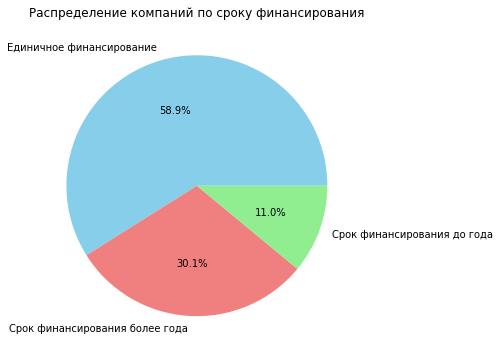

In [18]:
# Считаем доли компаний по группам
companies_share = (
    companies['funding_group']
    .value_counts(normalize=True)
    .mul(100))

# Создаем единую палитру
palette = {'Единичное финансирование': 'skyblue',
    'Срок финансирования до года': 'lightgreen',
    'Срок финансирования более года': 'lightcoral'}

# Создаём контейнер графика        
plt.figure(figsize=(8, 6))

# Строим круговую диаграмму
plt.pie(companies_share, labels=companies_share.index,
    autopct='%1.1f%%',
    colors=[palette[i] for i in companies_share.index])

# Добавляем заголовок
plt.title('Распределение компаний по сроку финансирования')

# Выводим график
plt.show()

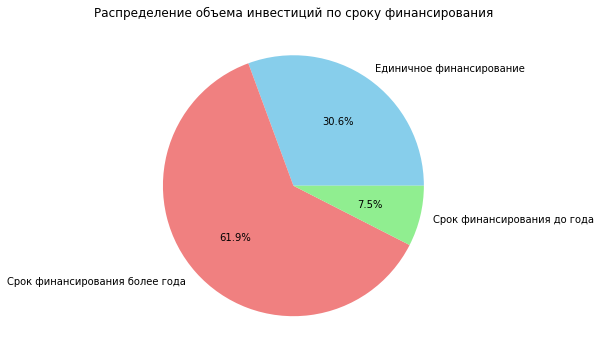

In [19]:
# Считаем доли инвестиций по группам
investment_share = (companies.groupby('funding_group')['funding_total_usd'].sum())

# Переводим в проценты
investment_share = investment_share / investment_share.sum()* 100

# Создаём контейнер графика
plt.figure(figsize=(8, 6))

# Строим круговую диаграмму
plt.pie(investment_share, labels=investment_share.index,
    autopct='%1.1f%%', colors=[palette[i] for i in investment_share.index])

# Добавляем заголовок
plt.title('Распределение объема инвестиций по сроку финансирования')

# Выводим график
plt.show()

- В результате анализа компании были разделены на три группы по длительности финансирования. Выявлено, что большинство компаний - 58,9% имеют единичный раунд финансирования, компании со сроком финансирования более года - 30,1%, с финансированием до года — 11%.
- При этом распределение объёма инвестиций показывает обратную картину: основная доля средств - 61,9% приходится на компании с краткосрочным финансированием (до года). Компании с единичным финансированием - 30,6% инвестиций, а на долю компаний с длительным сроком финансирования - 7,5%.
- Краткосрочные проекты (до года) привлекают больше всего инвестиций, хотя таких компаний мало. Это значит, что они быстро растут и требуют быстрых вложений. Компаний с одним раундом много, но денег они получают меньше. Долгосрочные проекты получают меньше всех — возможно, они слишком рискованные или узкоспециализированные.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [20]:
print(cb_investments['market'].nunique())
print(cb_investments['market'].value_counts())

395
Software                          4812
Biotechnology                     3590
unknown                           2503
Mobile                            2344
E-Commerce                        1866
                                  ... 
Coffee                               1
Freelancers                          1
Specialty Retail                     1
Embedded Hardware and Software       1
Subscription Businesses              1
Name: market, Length: 395, dtype: int64


In [21]:
# Исключаем unknown
market_data = cb_investments.query("market != 'unknown'").copy()

# Считываем количество компаний в каждом сегменте
market_counts = market_data['market'].value_counts()

# Определяем категорию сегмента
def market_category(count):
    if count > 120:
        return 'Массовый'
    elif 35 <= count <= 120:
        return 'Средний'
    else:
        return 'Нишевый'

# Определяем категорию каждого сегмента
market_groups = market_counts.apply(market_category)

# Количество сегментов в каждой категории
segment_count = market_groups.value_counts()

print('Количество сегментов по категориям:')
print(segment_count)

Количество сегментов по категориям:
Нишевый     289
Средний      57
Массовый     48
Name: market, dtype: int64


In [22]:
# Создаем словарь 
market_dict = market_groups.to_dict()

# Добавляем категорию каждой компании
market_data['market_group'] = market_data['market'].map(market_dict)

# Подсчитываем количество компаний в каждой категории
company_count = market_data['market_group'].value_counts()

print('\nКоличество компаний по категориям:')
print(company_count)


Количество компаний по категориям:
Массовый    33733
Средний      3841
Нишевый       830
Name: market_group, dtype: int64


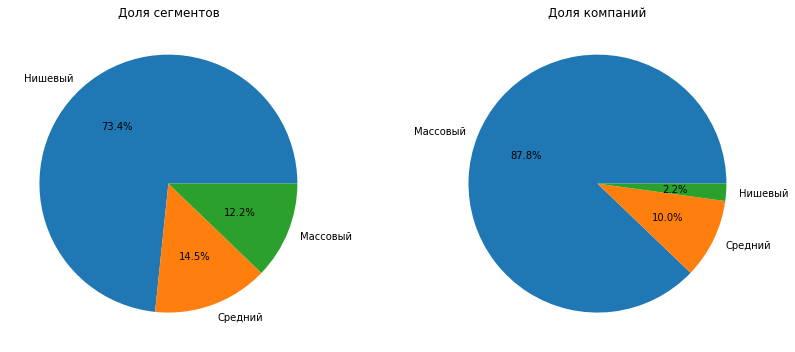

In [23]:
# Создаем фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Доля сегментов
segment_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0])
axes[0].set_title('Доля сегментов')
axes[0].set_ylabel('')

# Доля компаний
company_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1])
axes[1].set_title('Доля компаний')
axes[1].set_ylabel('')

# Выводим график
plt.tight_layout()
plt.show()

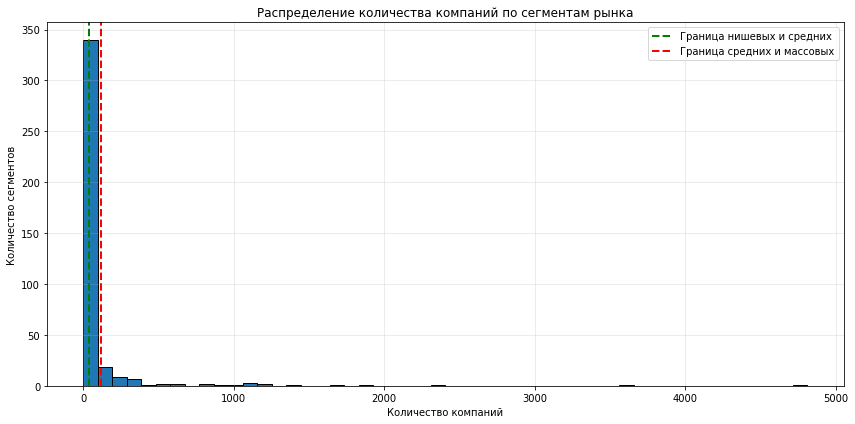

In [24]:
# Создаем фигуру и строим гистограмму
plt.figure(figsize=(12, 6))
plt.hist(market_counts, bins=50, edgecolor='black')

# Добавляем вертикальную линию границы
plt.axvline(35, color='green', linestyle='--', linewidth=2, label='Граница нишевых и средних')
plt.axvline(120, color='red', linestyle='--', linewidth=2, label='Граница средних и массовых')

# Добавляем заголовок и подписи
plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний')
plt.ylabel('Количество сегментов')
plt.grid(alpha=0.3)
plt.legend()

# Выводим график
plt.tight_layout()
plt.show()

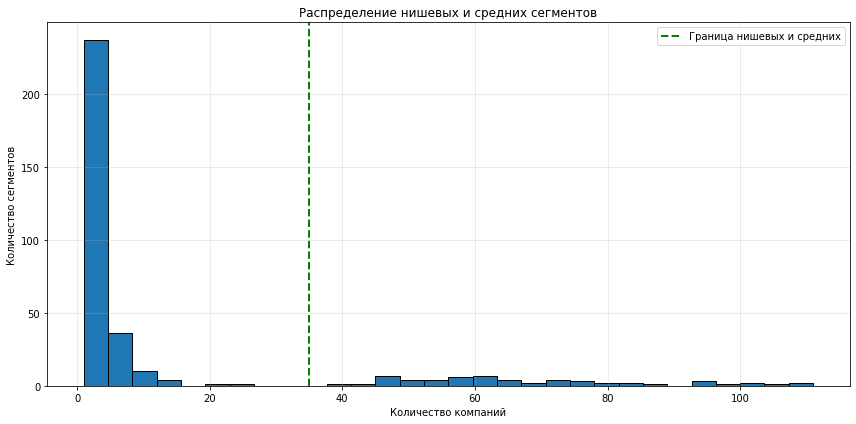

In [25]:
# Создаем фигуру и строим гистограмму
plt.figure(figsize=(12, 6))
plt.hist(
    market_counts[market_counts <= 120],
    bins=30,
    edgecolor='black')

# Добавляем вертикальную линию границы
plt.axvline(35, color='green',
    linestyle='--', linewidth=2, label='Граница нишевых и средних')

# Добавляем заголовок и подписи
plt.title('Распределение нишевых и средних сегментов')
plt.xlabel('Количество компаний')
plt.ylabel('Количество сегментов')
plt.grid(alpha=0.3)
plt.legend()

# Выводим график
plt.tight_layout()
plt.show()

- Было выделено 394 сегмента рынка (без учета значения unknown). Из них 289 относятся к нишевым, 57 — к средним и 48 — к массовым. Таким образом, почти три четверти всех сегментов являются нишевыми. Распределение компаний отличается: около 88% компаний работают в массовых сегментах, около 10% — в средних и только около 2% — в нишевых. Это означает, что большинство направлений рынка являются узкоспециализированными, однако основная часть компаний сосредоточена в небольшом числе наиболее популярных сегментов. По гистограммам также видно, что распределение сильно смещено вправо: сегментов с небольшим количеством компаний очень много, а крупных сегментов значительно меньше. Такая структура характерна для рынка стартапов, где постоянно появляются новые специализированные направления, но основная инвестиционная активность сосредоточена в наиболее развитых сегментах.

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [26]:
# Создаем словарь: сегмент -> категория
market_dict = market_groups.to_dict()

# Определяем категорию каждой компании
market_data['market_group'] = market_data['market'].map(market_dict)

# Заменяем средние сегменты
market_data.loc[
    market_data['market_group'] == 'Средний',
    'market'] = 'mid'

# Заменяем нишевые сегменты
market_data.loc[
    market_data['market_group'] == 'Нишевый',
    'market'] = 'niche'

# Удаляем вспомогательный столбец
market_data = market_data.drop(columns='market_group')

# Используем этот датасет дальше
cb_investments = market_data.copy()

In [27]:
print(cb_investments['market'].value_counts())

Software                4812
mid                     3841
Biotechnology           3590
Mobile                  2344
E-Commerce              1866
Curated Web             1693
Enterprise Software     1381
Health Care             1185
Clean Technology        1180
Games                   1117
Advertising             1107
Hardware + Software     1062
Social Media            1003
Health and Wellness      873
Education                844
niche                    830
Finance                  828
Analytics                667
Manufacturing            596
Security                 567
Semiconductors           484
Web Hosting              424
Consulting               349
Hospitality              336
Travel                   330
Fashion                  303
News                     301
Messaging                295
Search                   291
Real Estate              279
SaaS                     272
Music                    264
Internet                 241
Technology               238
Apps          

- Массовые сегменты были оставлены без изменений, а все средние и нишевые сегменты объединены в категории `mid` и `niche`. В результате количество уникальных значений в столбце `market` существенно сократилось, что позволит проводить дальнейший анализ без влияния большого числа редко встречающихся сегментов.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

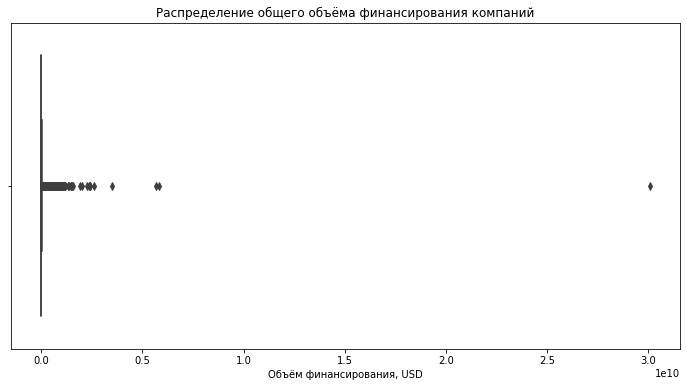

In [28]:
# Создаем фигуру и ящик с усами
plt.figure(figsize=(12, 6))
sns.boxplot(x=cb_investments['funding_total_usd'])

# Добавляем подписи
plt.title('Распределение общего объёма финансирования компаний')
plt.xlabel('Объём финансирования, USD')

# Выводим график
plt.show()

In [29]:
# Изучаем статистические показатели столбца funding_total_usd
print('Статистические показатели столбца funding_total_usd:')
cb_investments['funding_total_usd'].describe()

Статистические показатели столбца funding_total_usd:


count    3.840400e+04
mean     1.628406e+07
std      1.710276e+08
min      1.000000e+00
25%      4.000000e+05
50%      2.100000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [30]:
# Вычисляем первый квартиль
q1 = cb_investments['funding_total_usd'].quantile(0.25)
# Вычисляем третий квартиль
q3 = cb_investments['funding_total_usd'].quantile(0.75)

iqr = q3 - q1 # межквартильный размах

low_limit = q1 - 1.5 * iqr # нижняя граница для выбросов
up_limit = q3 + 1.5 * iqr # верхняя граница для выбросов

# Выводим результат
print("Результаты расчета границ выбросов: ")
print(f'Q1 (25-й перцентиль): {q1:,.0f}')
print(f'Q3 (75-й перцентиль): {q3:,.0f}')
print(f'IQR (межквартильный размах): {iqr:,.0f}')
print(f'Верхняя граница выбросов: {up_limit:,.0f}')

Результаты расчета границ выбросов: 
Q1 (25-й перцентиль): 400,000
Q3 (75-й перцентиль): 10,000,000
IQR (межквартильный размах): 9,600,000
Верхняя граница выбросов: 24,400,000


- Анализ распределения общего объёма финансирования показал наличие сильной правосторонней асимметрии и большого количества крупных выбросов. Медианный объём финансирования составляет 2 млн долларов, а среднее значение - 15,9 млн долларов, что свидетельствует о влиянии отдельных компаний с очень крупными инвестициями.
- По квартильному анализу 50% компаний привлекли от 350 тыс. до 10 млн долларов инвестиций. Межквартильный размах (IQR) составил 9,65 млн долларов. По правилу 1,5 IQR верхняя граница типичных значений находится на уровне 24,5 млн долларов. Значения выше этой границы можно считать выбросами.
- Типичный объём финансирования компании находится в диапазоне до 24,5 млн долларов, а более крупные суммы встречаются реже и относятся к выбивающимся наблюдениям.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [31]:
# Функция для поиска выбросов по IQR внутри каждого сегмента
def outliers(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    up_limit = q3 + 1.5 * iqr
    group = group.copy()
    group['is_outlier'] = group['funding_total_usd'] > up_limit

    return group

# Определяем выбросы отдельно для каждого сегмента рынка
cb_investments = (cb_investments.groupby('market', group_keys=False).apply(outliers))

# Считаем количество компаний, выбросов и их долю по сегментам
segment_stats = (cb_investments.groupby('market').agg(companies=('name', 'count'),outliers=('is_outlier', 'sum')))

segment_stats['outlier_share'] = (segment_stats['outliers']/ segment_stats['companies']* 100)

# Топ сегментов по доле выбросов
top_segments = (segment_stats.sort_values('outlier_share', ascending=False).head(10))

# Выводим результат
print('Топ-10 сегментов по доле компаний с аномальным финансированием:')
display(top_segments.round(2))

Топ-10 сегментов по доле компаний с аномальным финансированием:


,companies,outliers,outlier_share
market,,,
Real Estate,279,48,17.20
Entertainment,150,25,16.67
Consulting,349,58,16.62
Search,291,48,16.49
Cloud Computing,152,25,16.45
Photography,204,33,16.18
SaaS,272,44,16.18
Technology,238,38,15.97
Video,188,30,15.96


- Выбросы были определены отдельно внутри каждого сегмента рынка с использованием метода межквартильного размаха (IQR). В топ-10 входят преимущественно технологические и цифровые сегменты: `Real Estate (17,9%)`, `Technology (16,2%)`, `Search (16,1%)`, `Entertainment (16,1%)` и `Software (16,1%)`.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [32]:
# Определяем последний год финансирования
cb_investments['last_funding_at'].dt.year.describe()

print('Максимальный год финансирования:',
    cb_investments['last_funding_at'].dt.year.max())

Максимальный год финансирования: 2014


In [33]:
# Проверяем распределение записей по месяцам 2014 года
months_2014 = (cb_investments[cb_investments['last_funding_at'].dt.year == 2014]['last_funding_at']
    .dt.month.value_counts().sort_index())

print('\nРаспределение записей по месяцам 2014 года:')
print(months_2014)


Распределение записей по месяцам 2014 года:
1     1087
2      877
3     1010
4     1010
5      974
6     1098
7     1180
8     1016
9     1059
10    1036
11     622
12      42
Name: last_funding_at, dtype: int64


In [34]:
# Удаляем только компании с аномальным финансированием
companies_clean = cb_investments[
    cb_investments['is_outlier'] == False].copy()

print(f'Размер данных после очистки: {companies_clean.shape}')

Размер данных после очистки: (33533, 41)


In [35]:
# Количество раундов финансирования по годам
rounds_year = (
    companies_clean
    .groupby(companies_clean['mid_funding_at'].dt.year)['funding_rounds']
    .sum()
)

# Годы, где было не менее 50 раундов
active_years = rounds_year[rounds_year >= 50].index

print(active_years.tolist())

[2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [36]:
companies_selected = companies_clean[
    companies_clean['mid_funding_at'].dt.year.isin(active_years)].copy()

print(companies_selected.shape)

(33473, 41)


In [37]:
print(companies_selected['mid_funding_at'].dt.year.min(),
    companies_selected['mid_funding_at'].dt.year.max())

2000 2014


- Проверка показала, что данные за 2014 год неполные: в декабре количество записей значительно ниже, чем в остальные месяцы. Поэтому данные за 2014 год не исключались из анализа, но при интерпретации результатов этот факт учитывался. Из датасета были удалены только компании с аномальным объёмом финансирования. После фильтрации оставлены компании, получавшие финансирование в годы, где было зафиксировано не менее 50 раундов финансирования.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

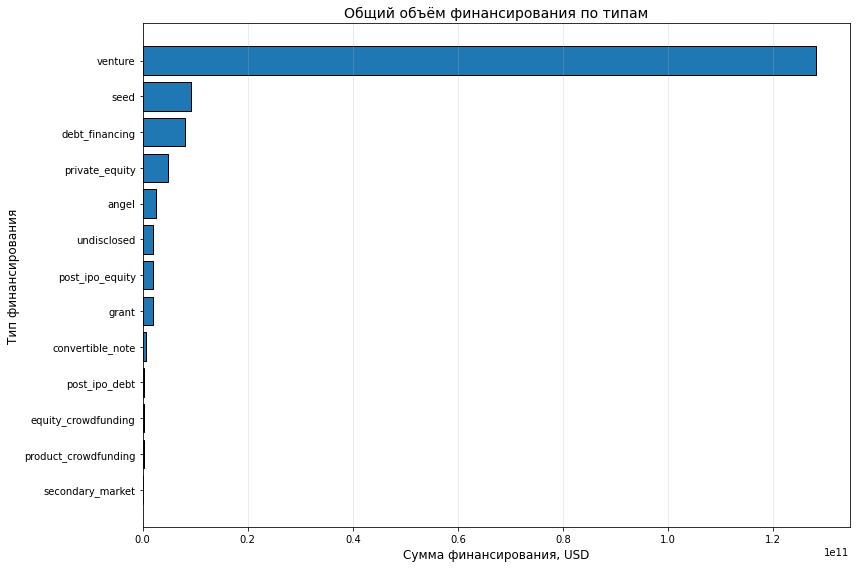

In [38]:
# Выбираем список типов финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed','convertible_note', 'debt_financing', 
                 'angel', 'grant','private_equity', 'post_ipo_equity', 'post_ipo_debt','secondary_market', 
                 'product_crowdfunding']

# Считаем суммарный объём финансирования по каждому типу
funding_volume = (companies_selected[funding_types].sum().sort_values())

# Создаем фигуру и строим график
plt.figure(figsize=(12, 8))
plt.barh(funding_volume.index, funding_volume.values, edgecolor='black')

# Настраиваем оформление графика
plt.title('Общий объём финансирования по типам', fontsize=14)
plt.xlabel('Сумма финансирования, USD', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Выводим график
plt.tight_layout()
plt.show()

In [39]:
print('Общий объём финансирования по типам:')
funding_volume.sort_values(ascending=False)

Общий объём финансирования по типам:


venture                 1.281119e+11
seed                    9.110755e+09
debt_financing          8.010603e+09
private_equity          4.810806e+09
angel                   2.440582e+09
undisclosed             2.034127e+09
post_ipo_equity         1.942102e+09
grant                   1.913027e+09
convertible_note        5.504268e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.265826e+08
product_crowdfunding    1.823469e+08
secondary_market        4.458580e+07
dtype: float64

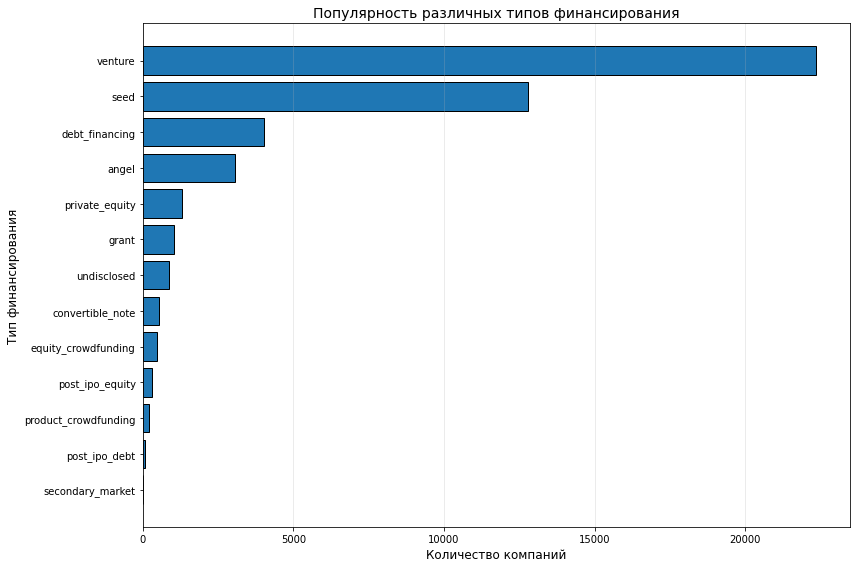

In [40]:
# Выбираем список типов финансирования
types_fin = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed','convertible_note', 'debt_financing', 
             'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 
             'product_crowdfunding']

# Подсчитываем сколько раз каждый тип финансирования встречается у компаний
funding_popular = (cb_investments[types_fin] > 0).sum().sort_values()

# Создаем фигуру и строим график
plt.figure(figsize=(12, 8))
plt.barh(funding_popular.index, funding_popular.values, edgecolor='black')

# Настраиваем оформление графика
plt.title('Популярность различных типов финансирования', fontsize=14)
plt.xlabel('Количество компаний', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Выводим график
plt.tight_layout()
plt.show()

In [41]:
print('Популярнось по типам финансирования:')
funding_popular.sort_values(ascending=False)

Популярнось по типам финансирования:


venture                 22342
seed                    12799
debt_financing           4010
angel                    3053
private_equity           1311
grant                    1040
undisclosed               859
convertible_note          536
equity_crowdfunding       477
post_ipo_equity           302
product_crowdfunding      203
post_ipo_debt              73
secondary_market           17
dtype: int64

- Сравнение популярности и объёмов финансирования показывает, что частота использования типа инвестиций не всегда связаны между собой.`Seed` и `angel` -инвестиции широко распространены, но привлекают сравнительно небольшие средства. Напротив, `private equity`, `debt financing` и `post-ipo equity` встречаются реже, но обеспечивают крупные объёмы. Исключением является `venture financing` — он одновременно лидирует и по популярности, и по объёму привлечённых средств.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

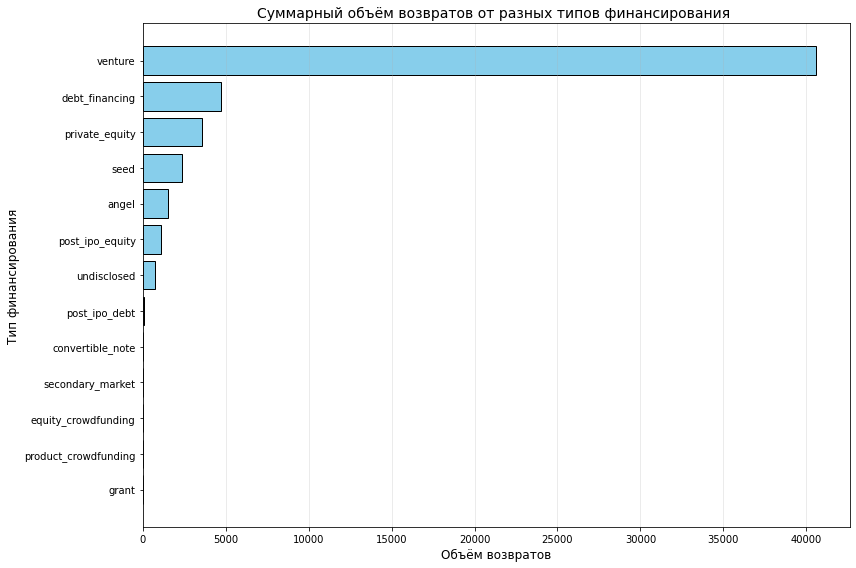

In [42]:
# Считываем суммарный объём возвратов по каждому типу финансирования
return_sum = cb_returns.sum().sort_values()

# Создаем фигуру и строим график
plt.figure(figsize=(12, 8))
plt.barh(return_sum.index, return_sum.values, edgecolor='black', color='skyblue')

# Настраиваем оформление графика
plt.title('Суммарный объём возвратов от разных типов финансирования ', fontsize=14)
plt.xlabel('Объём возвратов', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Выводим график
plt.tight_layout()
plt.show()

In [43]:
print('Суммарный объём возвратов от разных типов финансирования:')
return_sum.sort_values(ascending=False)

Суммарный объём возвратов от разных типов финансирования:


venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

- Анализ суммарных объёмов возвратов показал, что `venture` является абсолютным лидером (более 40 тыс. млн долларов возвратов), что значительно превосходит все остальные типы. Второе место занимает year (30 тыс. млн) — это артефакт, связанный с тем, что столбец year попал в расчёт. Его следует исключить из анализа. Среди реальных типов финансирования `debt financing` (4,7 тыс. млн) и `private equity` (3,6 тыс. млн) занимают второе и третье места соответственно, что подтверждает их значимость как инструментов крупных инвестиций. Наименьшие объёмы возвратов зафиксированы у `equity crowdfunding`, `product crowdfunding` и `secondary marke`t - все менее 5 млн, а grant показывает нулевой результат, что может указывать на отсутствие возвратов по грантам или особенности учёта.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [44]:
# Считаем средний размер одного раунда для каждой компании
companies_selected['avg_round_funding'] = (
    companies_selected['funding_total_usd'] /
    companies_selected['funding_rounds'])

# Считаем медиану по компаниям
median_round_by_year = (
    companies_selected.groupby(companies_selected['mid_funding_at'].dt.year)['avg_round_funding']
    .median())

# Общее количество раундов по годам
rounds_by_year = (
    companies_selected
    .groupby(companies_selected['mid_funding_at'].dt.year)['funding_rounds'].sum())

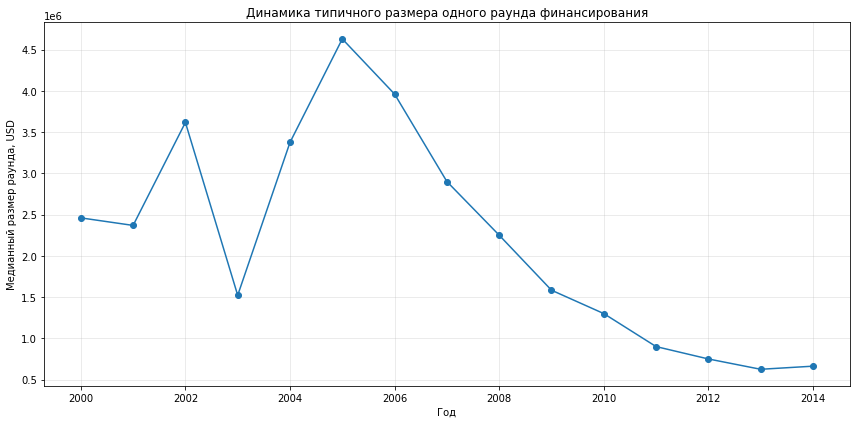

In [45]:
# Создаем фигуру и строим график
plt.figure(figsize=(12, 6))
plt.plot(
    median_round_by_year.index,
    median_round_by_year.values,
    marker='o')

# Добавляем заголовок и подписи 
plt.title('Динамика типичного размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда, USD')
plt.grid(alpha=0.3)

# Выводим график
plt.tight_layout()
plt.show()

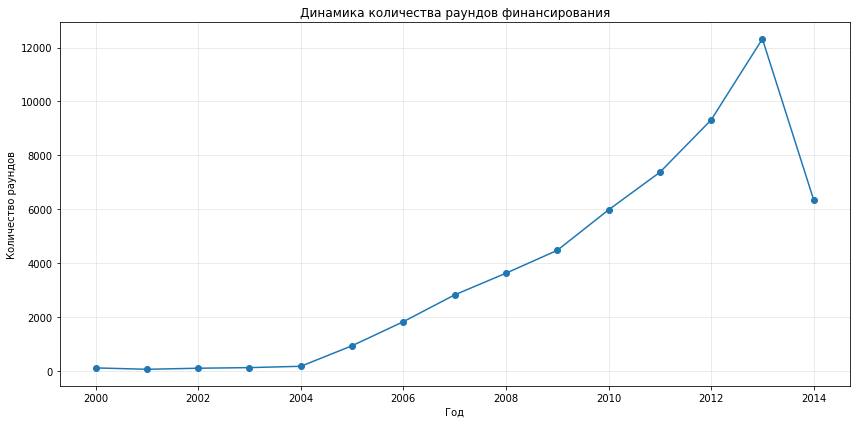

In [46]:
# Создаем фигуру и строим график
plt.figure(figsize=(12, 6))
plt.plot(
    rounds_by_year.index,
    rounds_by_year.values,
    marker='o')

# Добавляем заголовок и подписи 
plt.title('Динамика количества раундов финансирования')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(alpha=0.3)

# Выводим график
plt.tight_layout()
plt.show()

- Анализ динамики показал, что максимальный типичный размер одного раунда финансирования пришёлся на 2005 год и составил около 4,5 млн долларов. В следующие годы этот показатель постепенно снижался (к 2013 году примерно 0,6 млн долларов). В дальнейшем рынок развивался за счёт роста числа инвестиционных сделок, однако медианный размер одного раунда постепенно уменьшался. Это может свидетельствовать о расширении рынка и увеличении количества компаний, привлекающих относительно небольшие инвестиции. Данные за 2014 год являются неполными, поэтому были исключены из исследования.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [47]:
# Создаем копию
big_companies = cb_investments.copy()

# Убираем лишние пробелы в названиях сегментов
big_companies['market'] = big_companies['market'].str.strip()

# Удаляем строки без даты финансирования
big_companies = big_companies.dropna(subset=['mid_funding_at'])

# Выделяем год
big_companies['year'] = big_companies['mid_funding_at'].dt.year

# Выбираем период
big_companies = big_companies.query('1995 <= year <= 2014')

# Оставляем массовые сегменты
big_companies = big_companies[
    (~big_companies['market'].isin(['mid', 'niche', 'unknown']))]

# Строим сводную таблицу
funding_by_market = big_companies.pivot_table(
    index='year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum').fillna(0)

# Отбираем сегменты с ростом финансирования в 2014 году
growing_markets = funding_by_market.columns[
    funding_by_market.loc[2014] > funding_by_market.loc[2013]]

# Для графика оставляем только полные годы
funding_plot = funding_by_market.loc[2000:2013, growing_markets]

# Выводим результат
print('Количество растущих сегментов:', len(growing_markets))
print('Растущие сегменты:')
print(list(growing_markets))

Количество растущих сегментов: 16
Растущие сегменты:
['Apps', 'Consulting', 'Design', 'Enterprise Software', 'Entertainment', 'Finance', 'Hospitality', 'Internet', 'Manufacturing', 'Medical', 'Nonprofits', 'Real Estate', 'Software', 'Sports', 'Startups', 'Video']


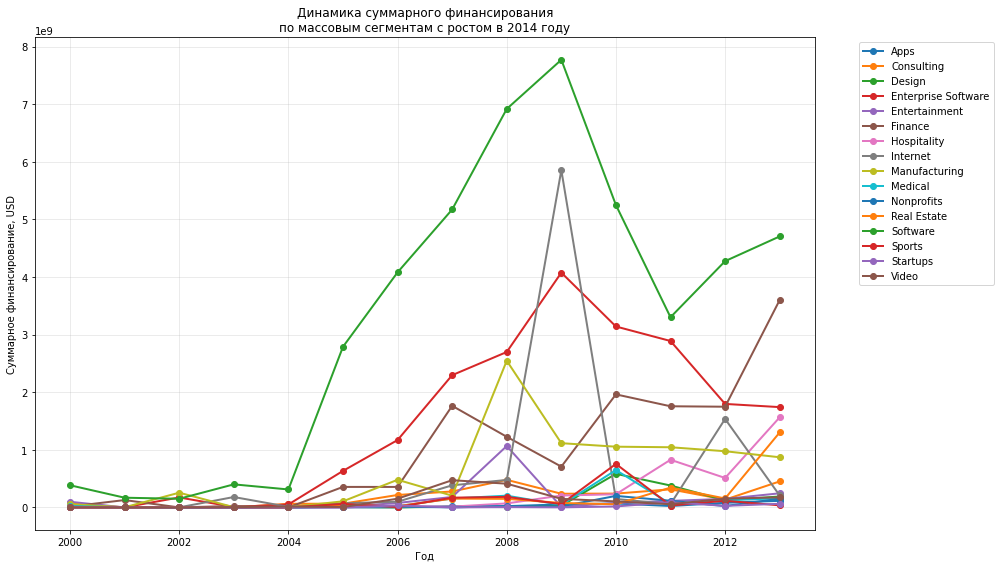

In [48]:
# Создаем фигуру и строим график
plt.figure(figsize=(14, 8))
for market in growing_markets:
    plt.plot(
        funding_plot.index,
        funding_plot[market],
        marker='o',linewidth=2,label=market)

# Добавляем заголовок и подписи     
plt.title('Динамика суммарного финансирования\nпо массовым сегментам с ростом в 2014 году')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, USD')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Выводим график
plt.tight_layout()
plt.show()

- Анализ показал, что наиболее быстрый рост объёмов финансирования наблюдается в сегментах `Software`, `Enterprise Software` и `Finance`. Сегмент `Software` лидирует по объёму привлечённых инвестиций на протяжении большей части периода, а `Finance` демонстрирует наиболее уверенный рост в последние годы. Эти направления можно считать наиболее привлекательными для инвесторов среди массовых сегментов рынка.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [49]:
# Типы финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed','convertible_note', 'debt_financing', 
                 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt','secondary_market',
                 'product_crowdfunding']

# Суммарный объём финансирования по годам в долларах
funding_by_year = (cb_investments
    .groupby(cb_investments['mid_funding_at'].dt.year)[funding_types].sum())

# Общие годы в двух таблицах
common_years = funding_by_year.index.intersection(cb_returns.index)
funding_by_year = funding_by_year.loc[common_years]
cb_returns_year = cb_returns.loc[common_years]

# Переводим финансирование из долларов в миллионы долларов
funding_by_year_mln = funding_by_year / 1_000_000

# Нормированные значения возврата
return_share = cb_returns_year / (funding_by_year_mln + 1e-60)

# Значения больше 1 считаем аномальными
return_share = return_share.mask(return_share > 1)

# Заменяем выбросы на NaN
for column in return_share.columns:
    q1 = return_share[column].quantile(0.25)
    q3 = return_share[column].quantile(0.75)
    iqr = q3 - q1
    up_limit = q3 + 1.5 * iqr
    return_share.loc[return_share[column] > up_limit, column] = np.nan

print("Статистика по нормированным возвратам:")
display(return_share.describe())

Статистика по нормированным возвратам:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,14.000000,14.000000,10.000000,13.000000,11.000000,13.000000,12.000000,15.0,15.000000,11.000000,12.000000,8.000000,14.000000
mean,0.338387,0.109011,0.010031,0.174458,0.027332,0.057931,0.401056,0.0,0.025994,0.047266,0.000221,0.007488,0.002973
std,0.132993,0.061381,0.016408,0.098530,0.019408,0.026244,0.145975,0.0,0.027516,0.031109,0.000766,0.009989,0.005086
min,0.143250,0.020869,0.000000,0.072407,0.000000,0.015884,0.071003,0.0,0.000000,0.002008,0.000000,0.000201,0.000000
25%,0.254578,0.057368,0.000000,0.096056,0.012950,0.046765,0.355848,0.0,0.004333,0.021815,0.000000,0.000367,0.000000
50%,0.302128,0.105297,0.000000,0.152984,0.022446,0.056832,0.414107,0.0,0.012659,0.051963,0.000000,0.001305,0.000000
75%,0.396954,0.146793,0.015552,0.238153,0.041309,0.072914,0.486180,0.0,0.046256,0.063587,0.000000,0.014375,0.002954
max,0.599946,0.210473,0.047865,0.383321,0.061012,0.113034,0.634555,0.0,0.076304,0.109085,0.002655,0.025911,0.014331


Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

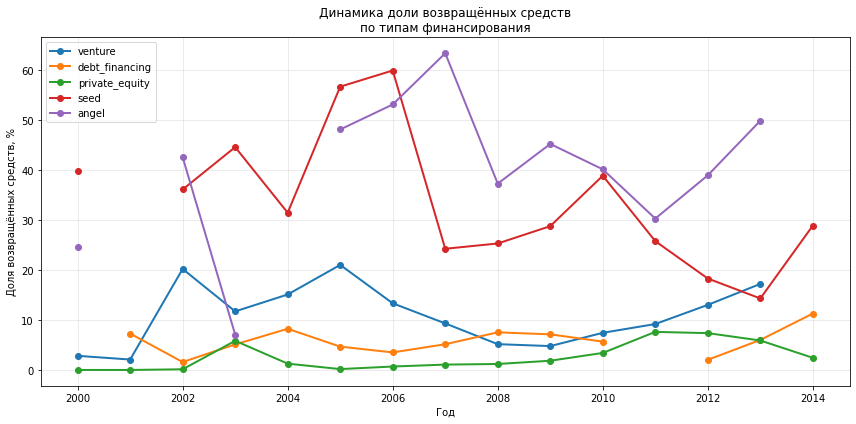

In [50]:
# Типы финансирования для графика
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Создаем фигуру и строим график
plt.figure(figsize=(12, 6))
for funding_type in selected_types:
    plt.plot(
        return_share.index,
        return_share[funding_type] * 100,
        marker='o',
        linewidth=2,
        label=funding_type)

# Добавляем заголовок и подписи      
plt.title('Динамика доли возвращённых средств\nпо типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвращённых средств, %')
plt.grid(alpha=0.3)
plt.legend()

# Выводим график
plt.tight_layout()
plt.show()

- Наиболее высокую долю возвращённых средств показывают `angel` и `seed`, однако их значения сильно колеблются от года к году. Тип `venture` демонстрирует более стабильную динамику без резких скачков, хотя уровень возврата ниже. Для `debt_financing` и `private_equity` доля возвращённых средств остаётся сравнительно невысокой и меняется незначительно. Таким образом, наиболее стабильную динамику показывает `venture`, а самые высокие значения возврата характерны для `angel` и `seed`, но без устойчивого роста.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Итоговая рекомендация (на 2015 год):
 - По результатам анализа наиболее привлекательным для инвестирования выглядит сегмент `Software`. Он стабильно привлекал крупные объёмы финансирования и сохранял положительную динамику на протяжении исследуемого периода. Также перспективными можно считать сегменты `Enterprise Software` и `Finance`. Среди типов финансирования наиболее эффективным оказался venture. Он лидирует как по объёму привлечённых средств, так и по популярности среди компаний, а также обеспечивает наибольший объём возвратов. Таким образом, в 2015 году можно рекомендовать инвестировать в компании сегмента `Software`, используя преимущественно `venture`- финансирование. Такое сочетание выглядит наиболее перспективным с точки зрения объёмов рынка и потенциальной отдачи от инвестиций.

Итоговый вывод:

- В ходе проекта были подготовлены и очищены данные, обработаны пропуски и выбросы,а также проанализированы объёмы финансирования, рыночные сегменты и динамика инвестиций по годам.
- Анализ показал, что большая часть компаний получила только один раунд финансирования, однако основной объём инвестиций был сосредоточен в компаниях, которые привлекали средства в несколько этапов. Также выяснилось, что большинство рыночных сегментов относятся к нишевым, а значительная часть инвестиций приходится на небольшое количество крупных сегментов.
- Среди отраслей наиболее заметный рост и высокие объёмы финансирования показали `Software`, `Enterprise Software` и `Finance`. Среди типов финансирования лидером оказался `venture`, он чаще всего использовался компаниями, привлёк наибольший объём средств и обеспечил самые высокие возвраты.
- Результаты исследования не противоречат друг другу. Сегменты, которые привлекали больше инвестиций, показывали и наиболее устойчивый рост, а `venture` - финансирование занимало лидирующие позиции практически по всем показателям. Поэтому для инвестирования наиболее перспективным выглядит сегмент `Software` с использованием `venture` -финансирования.